# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
df_calls = pd.read_csv('datasets/megaline_calls.csv')
df_internet = pd.read_csv('datasets/megaline_internet.csv')
df_messages = pd.read_csv('datasets/megaline_messages.csv')
df_plans = pd.read_csv('datasets/megaline_plans.csv')
df_users = pd.read_csv('datasets/megaline_users.csv')

## Preparar los datos

## Tarifas

In [3]:
# Print the summary information of the plans DataFrame
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [4]:
# Print a sample ofn the plans DataFrame
df_plans.head(10)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

**R.**
Los tipos de datos y la información se ve correcta y completa

### Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [5]:
# It's not identified the need to correct something

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [6]:
# it's not identified the need to enrich information 

## Usuarios/as

In [7]:
# Print the summary information of the users DataFrame
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Print a sample data for users
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

**R:**
- Must be replace churn_date NaN values with 0 values, the users are active still


### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

**R.**
- Count null values

In [9]:
df_users.isna().sum()

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

In [10]:
# Count duplicated values in users DataFrame
df_users.duplicated().sum()

np.int64(0)

- There are null values in churn_date, Doesn't exist duplicate values

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [11]:
# Must be replace churn_date NaN values with 0 values, the users are active still
df_users['churn_date'] = df_users['churn_date'].fillna(0)
# Verify the change
df_users.isna().sum()

user_id       0
first_name    0
last_name     0
age           0
city          0
reg_date      0
plan          0
churn_date    0
dtype: int64

## Llamadas

In [12]:
# Print the sumnary information of the calls Dataframe
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [13]:
# Print a sample of data calls
df_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

**R:**

- The call_date is object type, must be change to datetime type

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [14]:
# Validate if there are duplicate values
df_calls.duplicated().sum()

np.int64(0)

**R:**

- There are no null or duplicate values

In [15]:
# Convert call_date to datatime type
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
# Verify the change
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [16]:
# Month extraction from call_date
df_calls['month'] = df_calls['call_date'].dt.month
print(df_calls)

              id  user_id  call_date  duration  month
0        1000_93     1000 2018-12-27      8.52     12
1       1000_145     1000 2018-12-27     13.66     12
2       1000_247     1000 2018-12-27     14.48     12
3       1000_309     1000 2018-12-28      5.76     12
4       1000_380     1000 2018-12-30      4.22     12
...          ...      ...        ...       ...    ...
137730  1499_199     1499 2018-11-21      8.72     11
137731  1499_200     1499 2018-10-20     10.89     10
137732  1499_201     1499 2018-09-21      8.12      9
137733  1499_202     1499 2018-10-10      0.37     10
137734  1499_203     1499 2018-12-29     13.86     12

[137735 rows x 5 columns]


## Mensajes

In [17]:
# Print the summary information of the messages DataFrame
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [18]:
# Print a sample of the messages data
df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [19]:
# Validate if there are duplicate values in messages DataFrame
df_messages.duplicated().sum()
# Validate if there are null values in messages DataFrame
df_messages.isna().sum()

id              0
user_id         0
message_date    0
dtype: int64

**R:**

There are not duplicate o null values in messages DataFrame

In [20]:
# Convert message_date to datatime type
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])
# Verify the chage
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [21]:
# Extract month from message_date
df_messages['month'] = df_messages['message_date'].dt.month
print(df_messages)

             id  user_id message_date  month
0      1000_125     1000   2018-12-27     12
1      1000_160     1000   2018-12-31     12
2      1000_223     1000   2018-12-31     12
3      1000_251     1000   2018-12-27     12
4      1000_255     1000   2018-12-26     12
...         ...      ...          ...    ...
76046  1497_526     1497   2018-12-24     12
76047  1497_536     1497   2018-12-24     12
76048  1497_547     1497   2018-12-31     12
76049  1497_558     1497   2018-12-24     12
76050  1497_613     1497   2018-12-23     12

[76051 rows x 4 columns]


## Internet

In [22]:
# Print the summary information of the internet DataFrame
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [23]:
# Print a sample of data for internet DataFrame
df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [24]:
# Verify if there are duplicate values in internet DataFrame
df_internet.duplicated().sum()

np.int64(0)

In [25]:
# Verify if there are null values in internet DataFrame
df_internet.isna().sum()

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

**R:**
The are not duplicate or null values

In [26]:
# Convert session_date to datatime type
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])
# Verify the change
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [27]:
# Extract month from session_date
df_internet['month'] = df_internet['session_date'].dt.month
df_internet

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12
...,...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06,10
104821,1499_216,1499,2018-12-30,304.72,12
104822,1499_217,1499,2018-09-22,292.75,9
104823,1499_218,1499,2018-12-07,0.00,12


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [28]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [29]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

metrics_calls = df_calls.pivot_table(index=['user_id', 'month'], values='duration', aggfunc=['sum', 'count']).reset_index()
metrics_calls.columns = ['user_id', 'month', 'total_minute_duration', 'total_calls_count']
metrics_calls

,user_id,month,total_minute_duration,total_calls_count
0,1000,12,116.83,16
1,1001,8,171.14,27
2,1001,9,297.69,49
3,1001,10,374.11,65
4,1001,11,404.59,64
...,...,...,...,...
2253,1498,12,324.77,39
2254,1499,9,330.37,41
2255,1499,10,363.28,53
2256,1499,11,288.56,45


In [30]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
# Round the total minute duration to the upper integer, because the company charge by minute, and if the user use 1.5 minutes, the company charge 2 minutes.
def minute_round(row):
    return math.ceil(row)

metrics_calls['total_round_minutes'] = metrics_calls['total_minute_duration'].apply(minute_round)
metrics_calls = metrics_calls.loc[:, ['user_id', 'month', 'total_round_minutes', 'total_calls_count']]
metrics_calls


,user_id,month,total_round_minutes,total_calls_count
0,1000,12,117,16
1,1001,8,172,27
2,1001,9,298,49
3,1001,10,375,65
4,1001,11,405,64
...,...,...,...,...
2253,1498,12,325,39
2254,1499,9,331,41
2255,1499,10,364,53
2256,1499,11,289,45


In [31]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

metrics_messages = df_messages.pivot_table(index=['user_id', 'month'], values='id', aggfunc='count')
metrics_messages.columns = ['total_messages']
metrics_messages.reset_index(inplace=True)
metrics_messages

,user_id,month,total_messages
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,9,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


In [32]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

# Round mb according to the upper integer
def mb_round(row):
    return math.ceil(row)

metrics_internet = df_internet.pivot_table(index=['user_id', 'month'], values='mb_used', aggfunc='sum')
metrics_internet.reset_index(inplace=True)
metrics_internet['mb_used'] = metrics_internet['mb_used'].apply(mb_round)
metrics_internet

,user_id,month,mb_used
0,1000,12,1902
1,1001,8,6920
2,1001,9,13315
3,1001,10,22331
4,1001,11,18505
...,...,...,...
2272,1498,12,23138
2273,1499,9,12985
2274,1499,10,19493
2275,1499,11,16814


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [33]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Merge calls users Dataframe to get the plan column
accumulated = metrics_calls.merge(metrics_messages, how='outer', on=['user_id', 'month'])
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages
0,1000,12,117.0,16.0,11.0
1,1001,8,172.0,27.0,30.0
2,1001,9,298.0,49.0,44.0
3,1001,10,375.0,65.0,53.0
4,1001,11,405.0,64.0,36.0
...,...,...,...,...,...
2286,1498,12,325.0,39.0,NaN
2287,1499,9,331.0,41.0,NaN
2288,1499,10,364.0,53.0,NaN
2289,1499,11,289.0,45.0,NaN


In [34]:
accumulated.info()
accumulated[accumulated['total_round_minutes'].isna()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2291 non-null   int64  
 1   month                2291 non-null   int32  
 2   total_round_minutes  2258 non-null   float64
 3   total_calls_count    2258 non-null   float64
 4   total_messages       1806 non-null   float64
dtypes: float64(3), int32(1), int64(1)
memory usage: 80.7 KB


,user_id,month,total_round_minutes,total_calls_count,total_messages
94,1028,2,NaN,NaN,12.0
381,1080,8,NaN,NaN,31.0
382,1080,9,NaN,NaN,64.0
383,1080,10,NaN,NaN,59.0
384,1080,11,NaN,NaN,50.0
385,1080,12,NaN,NaN,61.0
426,1089,12,NaN,NaN,27.0
568,1121,11,NaN,NaN,1.0
569,1121,12,NaN,NaN,97.0
614,1131,5,NaN,NaN,18.0


In [35]:
accumulated.fillna(0, inplace=True)
accumulated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2291 non-null   int64  
 1   month                2291 non-null   int32  
 2   total_round_minutes  2291 non-null   float64
 3   total_calls_count    2291 non-null   float64
 4   total_messages       2291 non-null   float64
dtypes: float64(3), int32(1), int64(1)
memory usage: 80.7 KB


In [36]:
accumulated = accumulated.merge(df_users, how='inner', on='user_id')
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,0
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2286,1498,12,325.0,39.0,0.0,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,0
2287,1499,9,331.0,41.0,0.0,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,0
2288,1499,10,364.0,53.0,0.0,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,0
2289,1499,11,289.0,45.0,0.0,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,0


In [37]:
accumulated = accumulated.merge(metrics_internet, how='outer', on=['user_id', 'month'])
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,plan,churn_date,mb_used
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45.0,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,0,1902.0
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,6920.0
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,13315.0
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,22331.0
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,18505.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,12,325.0,39.0,0.0,Scot,Williamson,51.0,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,0,23138.0
2289,1499,9,331.0,41.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,0,12985.0
2290,1499,10,364.0,53.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,0,19493.0
2291,1499,11,289.0,45.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,0,16814.0


In [38]:
# Añade la información de la tarifa

accumulated = accumulated.merge(df_plans, how='inner', left_on='plan', right_on='plan_name')
accumulated


,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,...,churn_date,mb_used,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45.0,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,...,0,1902.0,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,0,6920.0,50,15360,500,20,10,0.03,0.03,surf
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,0,13315.0,50,15360,500,20,10,0.03,0.03,surf
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,0,22331.0,50,15360,500,20,10,0.03,0.03,surf
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,0,18505.0,50,15360,500,20,10,0.03,0.03,surf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2286,1498,12,325.0,39.0,0.0,Scot,Williamson,51.0,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,...,0,23138.0,50,15360,500,20,10,0.03,0.03,surf
2287,1499,9,331.0,41.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,0,12985.0,50,15360,500,20,10,0.03,0.03,surf
2288,1499,10,364.0,53.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,0,19493.0,50,15360,500,20,10,0.03,0.03,surf
2289,1499,11,289.0,45.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,0,16814.0,50,15360,500,20,10,0.03,0.03,surf


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [39]:
# Calcula el ingreso mensual para cada usuario

def total_payment(row):
    payment = row['usd_monthly_pay']

    if row['total_round_minutes'] > row['minutes_included']:
        payment += row['total_round_minutes'] - row['minutes_included'] * row['usd_per_minute']

    if row['total_messages'] > row['messages_included']:
        payment += row['total_messages'] - row['messages_included'] * row['usd_per_message']

    if row['mb_used'] > row['mb_per_month_included']:
        payment += math.ceil((row['mb_used'] - row['mb_per_month_included'])/1024) * row['usd_per_gb']

    return payment

In [40]:
accumulated['payment'] = accumulated.apply(total_payment, axis=1)
accumulated

,user_id,month,total_round_minutes,total_calls_count,total_messages,first_name,last_name,age,city,reg_date,...,mb_used,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,payment
0,1000,12,117.0,16.0,11.0,Anamaria,Bauer,45.0,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,...,1902.0,1000,30720,3000,70,7,0.01,0.01,ultimate,70.0
1,1001,8,172.0,27.0,30.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,6920.0,50,15360,500,20,10,0.03,0.03,surf,20.0
2,1001,9,298.0,49.0,44.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,13315.0,50,15360,500,20,10,0.03,0.03,surf,20.0
3,1001,10,375.0,65.0,53.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,22331.0,50,15360,500,20,10,0.03,0.03,surf,141.5
4,1001,11,405.0,64.0,36.0,Mickey,Wilkerson,28.0,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,...,18505.0,50,15360,500,20,10,0.03,0.03,surf,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2286,1498,12,325.0,39.0,0.0,Scot,Williamson,51.0,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,...,23138.0,50,15360,500,20,10,0.03,0.03,surf,100.0
2287,1499,9,331.0,41.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,12985.0,50,15360,500,20,10,0.03,0.03,surf,20.0
2288,1499,10,364.0,53.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,19493.0,50,15360,500,20,10,0.03,0.03,surf,70.0
2289,1499,11,289.0,45.0,0.0,Shena,Dickson,37.0,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,...,16814.0,50,15360,500,20,10,0.03,0.03,surf,40.0


In [41]:
accumulated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2291 entries, 0 to 2290
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2291 non-null   int64  
 1   month                  2291 non-null   int32  
 2   total_round_minutes    2291 non-null   float64
 3   total_calls_count      2291 non-null   float64
 4   total_messages         2291 non-null   float64
 5   first_name             2291 non-null   object 
 6   last_name              2291 non-null   object 
 7   age                    2291 non-null   float64
 8   city                   2291 non-null   object 
 9   reg_date               2291 non-null   object 
 10  plan                   2291 non-null   object 
 11  churn_date             2291 non-null   object 
 12  mb_used                2275 non-null   float64
 13  messages_included      2291 non-null   int64  
 14  mb_per_month_included  2291 non-null   int64  
 15  minu

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

<Axes: xlabel='plan'>

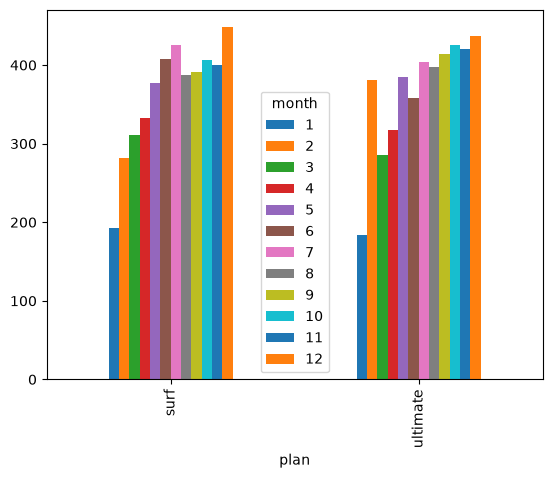

In [42]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
accumulated.groupby(['plan', 'month'])['total_round_minutes'].mean().unstack().plot(kind='bar')

plan
surf        405.24857
ultimate    407.83844
Name: total_round_minutes, dtype: float64

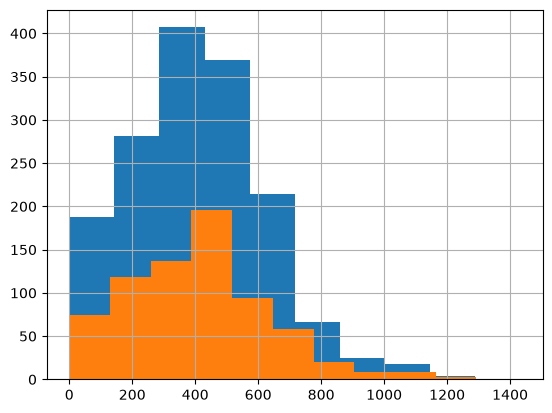

In [43]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
# accumulated.groupby('plan')['total_round_minutes'].mean().plot(kind='hist')
accumulated.query('plan == "surf"')['total_round_minutes'].hist()
accumulated.query('plan == "ultimate"')['total_round_minutes'].hist()

accumulated.groupby('plan')['total_round_minutes'].mean()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [44]:
# Calcula la media y la varianza de la duración mensual de llamadas.
accumulated.groupby('plan')['total_round_minutes'].agg(['mean', 'var'])

,mean,var
plan,,
surf,405.24857,49142.324306
ultimate,407.83844,51331.251407


<Axes: xlabel='plan', ylabel='total_round_minutes'>

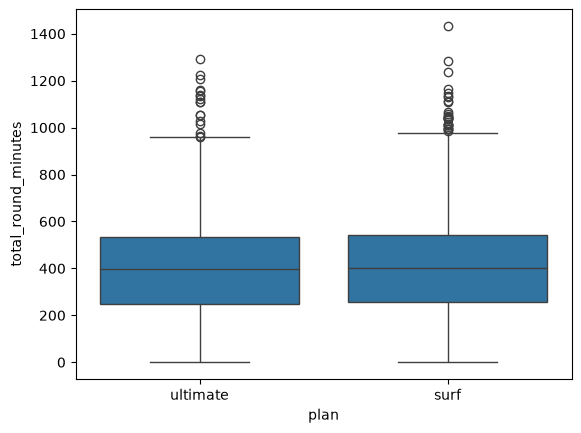

In [45]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(x='plan', y='total_round_minutes', data=accumulated)

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

**R**
- Total average minutes by months are longer in Ultimate than in Surf for some months, like month 2
- Just in month 6 Surf is longer than Ultimate
- The mean minutes for Surf and Ultimate are similar

### Mensajes

<Axes: xlabel='plan'>

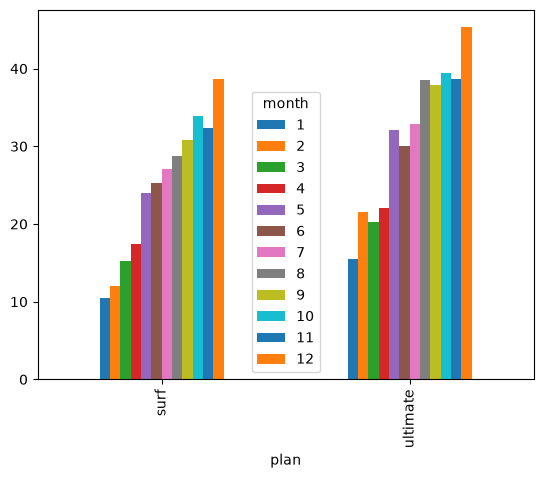

In [46]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
accumulated.groupby(['plan', 'month'])['total_messages'].mean().unstack().plot(kind='bar')


In [47]:
# Calcula la media y la varianza del numero de mensajes
accumulated.groupby('plan')['total_messages'].agg(['mean', 'var'])

,mean,var
plan,,
surf,31.159568,1126.724522
ultimate,37.655989,1208.184141


<Axes: xlabel='plan', ylabel='total_messages'>

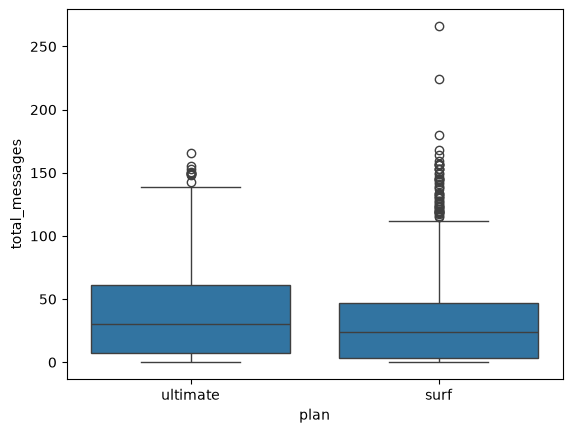

In [48]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(x='plan', y='total_messages', data=accumulated)

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

**R**
- There is a slightly higher consumption of minutes in the Ultimate plan than in Surf
- In Surf plan are more outliers values

### Internet

<Axes: xlabel='plan'>

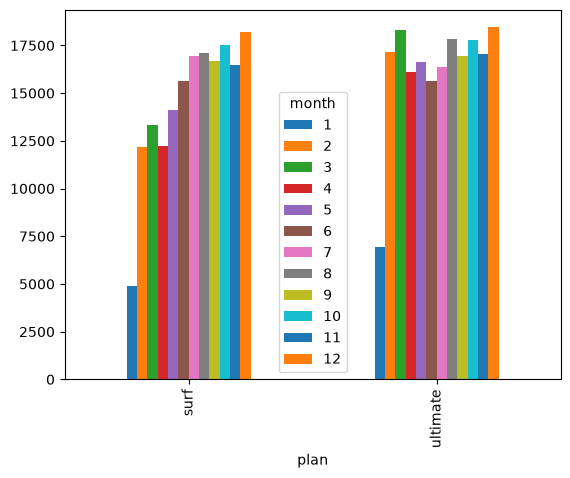

In [49]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
accumulated.groupby(['plan', 'month'])['mb_used'].mean().unstack().plot(kind='bar')

In [50]:
# Calcula la media y la varianza del tráfico de internet
accumulated.groupby('plan')['mb_used'].agg(['mean', 'var'])

,mean,var
plan,,
surf,16718.197047,6.216815e+07
ultimate,17284.813110,6.074395e+07


<Axes: xlabel='plan', ylabel='mb_used'>

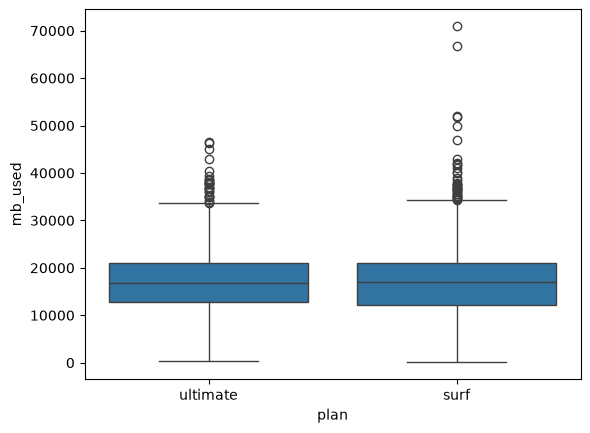

In [51]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(x='plan', y='mb_used', data=accumulated)

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

**R**
- Total average megabytes by months are longer in Ulitmate plan than in Surf plan

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

<Axes: xlabel='plan'>

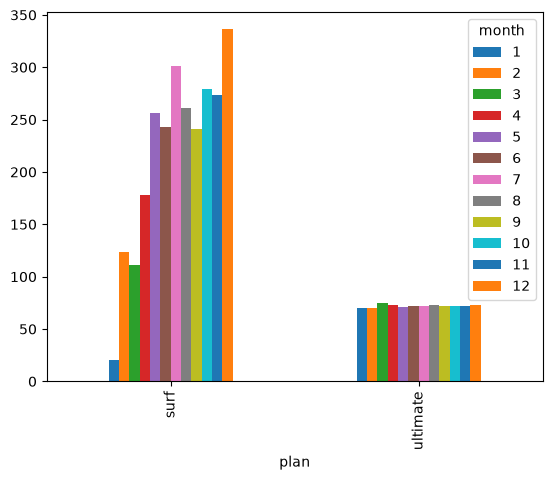

In [52]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
accumulated.groupby(['plan', 'month'])['payment'].mean().unstack().plot(kind='bar')

In [53]:
# Calcula la media y la varianza del tráfico de internet
accumulated.groupby('plan')['payment'].agg(['mean', 'var'])

,mean,var
plan,,
surf,274.353465,110220.278291
ultimate,72.320334,130.195709


<Axes: xlabel='plan', ylabel='payment'>

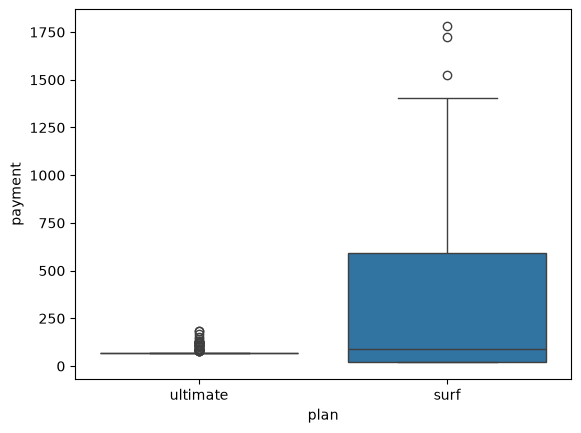

In [54]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
sns.boxplot(x='plan', y='payment', data=accumulated)

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

**R:**

- Ultimate plan is more stable than Surf plan
- The Surf plan has variable incomes and more expensives


## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [55]:
# Prueba las hipótesis
# H0: El promedio mensual de surf y ultimate son iguales
# H1: El promedio mensual de surf es distinto al de ultimate
grupo_surf = accumulated.query('plan == "surf"')['payment']
grupo_ultimate = accumulated.query('plan == "ultimate"')['payment']

[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [56]:
# Prueba las hipótesis
result = stats.ttest_ind(grupo_surf, grupo_ultimate)

if result.pvalue < (1 - 0.95):
    print('Rechazamos la hipotesis nula')
else:
    print('No Rechazamos la hipotesis nula')

Rechazamos la hipotesis nula


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

**R:**

- The Ultimate plan consume has a good configuration regarding to the MB, minutes and messages
- The Surf plan is more profitable than the Ultimate plan
- The high cost-effective could lead to dissatisfied customers